In [1]:
from dmri.simulators.sphereical_distributions import Watson, Bingham, inverse_sh_matrix, real_sh, HemiSphere, sphere_default, hemisphere_default
from dmri.simulators.local_signal_models import Stick
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt


/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:20: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere_default = get_sphere("symmetric724")
/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:23: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  big_sphere = get_sphere("repulsion724")


In [2]:
dist = Watson(jnp.array([1.0,0.0]), 0.1)

In [3]:
dist = Bingham(jnp.array([1.0,0]), 0.1,0.5*jnp.pi,0.5)

In [4]:
sphere = sphere_default

In [5]:
pdfs = dist.pdf(sphere.vertices)


0.0


In [7]:
samples = jax.random.normal(jax.random.PRNGKey(0), (1000000,3))
samples = samples/jnp.linalg.norm(samples, axis=-1, keepdims=True)
pdfs = dist.pdf(samples)

# Integrate the pdf over the sphere
jnp.mean(pdfs) * jnp.pi * 4

0.0


Array(0.9976051, dtype=float32)

In [8]:
pdfs[0]

Array(0.0129267, dtype=float32)

In [9]:
samples = dist.sample(jax.random.key(1), (5_000,))

In [10]:
samples.shape

(5000, 3)

ValueError: 'c' argument has 1000000 elements, which is inconsistent with 'x' and 'y' with size 724.

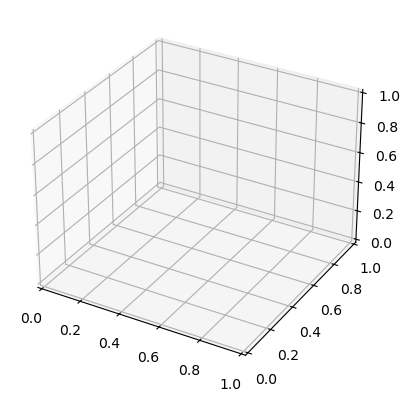

In [11]:
%matplotlib inline
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# plot sphere vertices colored by their pdf
sc = ax.scatter(sphere.vertices[:, 0],
                sphere.vertices[:, 1],
                sphere.vertices[:, 2],
                c=pdfs, cmap='viridis')
# overlay sample points in red
# ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2],
#            color='red', s=10, alpha=0.1, label='Samples')
plt.colorbar(sc, label='PDF value')
ax.set_title('Spherical Distribution PDF')
ax.legend()
plt.show()

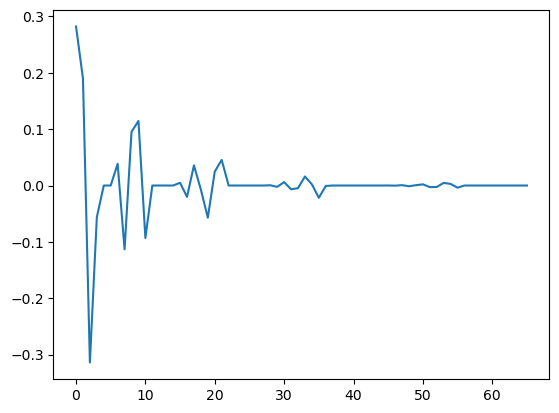

In [48]:
plt.plot(dist.sh_coeff())

In [50]:
dist.sh_coeff(sh_order=14).sum()

Array(0.15981317, dtype=float32)

In [51]:
1/4**0.5

0.5

In [52]:
vals = jax.random.normal(jax.random.PRNGKey(0), (1000, 3))
vals = vals / jnp.linalg.norm(vals, axis=1)[:, None]
hemisphere = HemiSphere(xyz=vals)

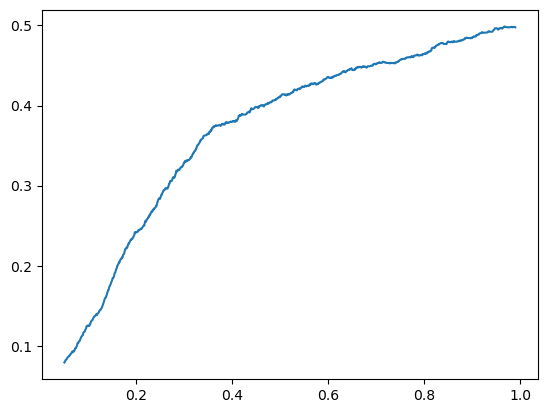

In [62]:
def kernel(v):
    return jnp.exp(-jnp.dot(v, jnp.array([1.0, 1.0, 1.0]))**2)


# Spherical convolution naive
def naive_spherical_convolution(mu, odi, kernel):
    dist = Watson(mu, odi)
    samples = dist.sample(jax.random.key(3), (1_000,))
    return jnp.mean(kernel(samples), axis=0)

mu = jnp.array([1.0, 0.5])
odi = 0.5

signals_mc = jax.vmap(lambda o: naive_spherical_convolution(mu, o, kernel))(jnp.linspace(0.05, 0.99, 1000))
plt.plot((jnp.linspace(0.05, 0.99, 1000)), signals_mc)

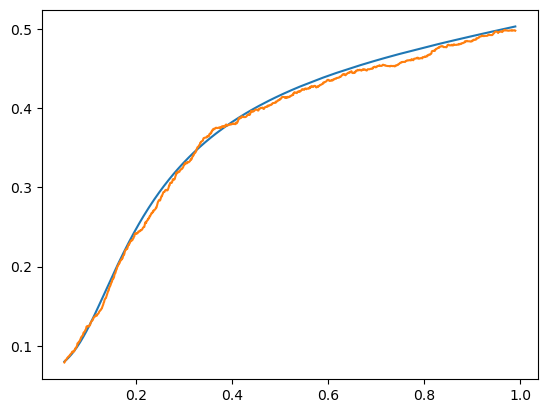

In [63]:
sh_coeff_kernel = inverse_sh_matrix(14, sphere=hemisphere)@kernel(hemisphere.vertices)

def sh_spherical_convolution(mu, odi):
    dist = Watson(mu, odi)
    sh_coeff = dist.sh_coeff(14, sphere=hemisphere)
    return jnp.dot(sh_coeff, sh_coeff_kernel)


signals = jax.vmap(lambda o: sh_spherical_convolution(mu, o))(jnp.linspace(0.05, 0.99, 1000))
_ = plt.plot(jnp.linspace(0.05, 0.99, 1000), signals)
_ = plt.plot(jnp.linspace(0.05, 0.99, 1000),signals_mc)

In [108]:
hemisphere = hemisphere_default
import numpy as np
dist = Bingham.from_theta(np.random.rand(Bingham.theta_dim))

dist = Bingham(jnp.array([1.0,0]), 0.1,1.,0.5)

In [109]:
# naive spherical convolution

bvals = jnp.linspace(0, 3000, 100)
bvecs = jax.random.normal(jax.random.key(1), (bvals.shape[0], 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

@jax.vmap
def stick_signal(vertices):
    return jax.vmap(Stick(0.1, vertices).signal)(bvals, bvecs)

samples = dist.sample(jax.random.key(4), (20_000,))
signal = stick_signal(samples)
signal_mean = jnp.mean(signal, axis=0)
signal_mean

Array([1.        , 0.58402854, 0.36391294, 0.27818343, 0.10249774,
       0.3570417 , 0.14727297, 0.17131084, 0.1020625 , 0.11585739,
       0.07131381, 0.23882848, 0.2884459 , 0.08482749, 0.09280362,
       0.01503822, 0.03231628, 0.15107809, 0.20084415, 0.15511268,
       0.08606078, 0.20797372, 0.02358327, 0.03785382, 0.22682333,
       0.02754021, 0.01971149, 0.03039027, 0.09226684, 0.1628989 ,
       0.01372035, 0.10073981, 0.18941438, 0.20952544, 0.12087351,
       0.01250047, 0.17569828, 0.10725417, 0.04227897, 0.03866432,
       0.04358851, 0.02762767, 0.02267139, 0.06658357, 0.041915  ,
       0.15963   , 0.07025319, 0.10738762, 0.14092973, 0.12718906,
       0.00993564, 0.01498225, 0.01581028, 0.05211842, 0.0353069 ,
       0.10999545, 0.00881256, 0.025102  , 0.12613909, 0.0084007 ,
       0.15999648, 0.01563156, 0.01556949, 0.07164604, 0.04802335,
       0.03338837, 0.0313547 , 0.10863159, 0.02256136, 0.01274887,
       0.01993484, 0.06397143, 0.09613001, 0.0230614 , 0.08866

In [110]:
sh_coeff = dist.sh_coeff(22, sphere=hemisphere)

In [111]:
sh_coeff_stick_kernel = inverse_sh_matrix(22, sphere=hemisphere)@stick_signal(hemisphere.vertices).squeeze()
sh_coeff_stick_kernel.shape

(276, 100)

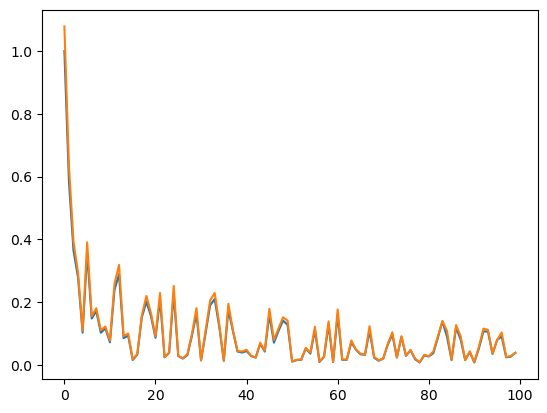

In [113]:
convoluted_signal = jnp.dot(sh_coeff, sh_coeff_stick_kernel)
plt.plot(signal_mean)
plt.plot(convoluted_signal*2)

In [16]:
L = 14
basis = real_sh(L, hemisphere.theta, hemisphere.phi)[0]
sh_coeff = dist.sh_coeff(sh_order=L, sphere=hemisphere)

In [46]:
basis.shape

(1000, 120)

In [17]:
pdfs_half = dist.pdf(hemisphere.vertices)
pdf_rec = basis @ sh_coeff

In [20]:
func_vals = stick_signal(hemisphere.vertices)

In [47]:
func_vals.shape

(1000, 100)

In [56]:
sh_coeff_model = inverse_sh_matrix(L, sphere=hemisphere) @ func_vals

In [58]:
sh_coeff_model.shape

(120, 100)

In [49]:
sh_coeff_model.shape, sh_coeff.shape

((120, 100), (120,))

In [ ]:
(sh_coeff_model[:, None,:] * sh_coeff[None,:, None]).shape

(120, 120, 100)

In [ ]:
convolved_sh_coeff = jnp.sum((sh_coeff_model[:, None,:] * sh_coeff[None,:, None]), axis=0)
convolved_sh_coeff.shape

(120, 100)

In [74]:
reconstructed_signal = basis @ convolved_sh_coeff

In [76]:
reconstructed_signal.shape

(1000, 100)

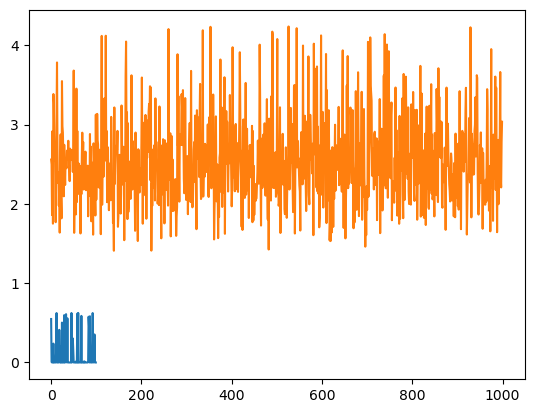

In [43]:
_ = plt.plot(reconstructed_signal, color="C1")
plt.plot(signal_mean)